In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [6]:
df = pd.read_excel("Online Retail.xlsx")

In [7]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
print("Rows and Columns:", df.shape)

Rows and Columns: (541909, 8)


In [9]:
print(df.columns.tolist())

['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [11]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [12]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [13]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [14]:
df = df.dropna(subset=["CustomerID"])

In [15]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [16]:
df["CustomerID"] = df["CustomerID"].astype(int)

In [17]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [18]:
df["InvoiceDate"].dtype

dtype('<M8[ns]')

In [19]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 5225


In [20]:
df = df.drop_duplicates()

In [21]:
print("Duplicate Rows After Cleaning:", df.duplicated().sum())

Duplicate Rows After Cleaning: 0


In [22]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [23]:
print(df["Quantity"].min())

1


In [24]:
df = df[df["Quantity"] > 0]

In [25]:
df = df[df["UnitPrice"] > 0]

In [26]:
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

In [27]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [28]:
print("Rows after cleaning:", len(df))
print("Unique customers:", df["CustomerID"].nunique())

Rows after cleaning: 392692
Unique customers: 4338


In [29]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Reference Date:", reference_date)

Reference Date: 2011-12-10 12:50:00


In [30]:
recency = df.groupby("CustomerID").agg(
    LastPurchase=("InvoiceDate", "max")
)

recency["Recency"] = (
    reference_date - recency["LastPurchase"]
).dt.days

In [31]:
recency.head()

,LastPurchase,Recency
CustomerID,,
12346,2011-01-18 10:01:00,326
12347,2011-12-07 15:52:00,2
12348,2011-09-25 13:13:00,75
12349,2011-11-21 09:51:00,19
12350,2011-02-02 16:01:00,310


In [32]:
frequency = df.groupby("CustomerID").agg(
    Frequency=("InvoiceNo", "nunique")
)

In [33]:
frequency.head()

,Frequency
CustomerID,
12346,1
12347,7
12348,4
12349,1
12350,1


In [34]:
monetary = df.groupby("CustomerID").agg(
    Monetary=("TotalAmount", "sum")
)

In [35]:
monetary.head()

,Monetary
CustomerID,
12346,77183.60
12347,4310.00
12348,1797.24
12349,1757.55
12350,334.40


In [36]:
rfm = recency[["Recency"]].join(
    frequency[["Frequency"]]
).join(
    monetary[["Monetary"]]
)

In [37]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [38]:
print("Average Recency:", rfm["Recency"].mean())
print("Average Purchase Frequency:", rfm["Frequency"].mean())
print("Average Monetary Value:", rfm["Monetary"].mean())

Average Recency: 92.53642231443061
Average Purchase Frequency: 4.272014753342554
Average Monetary Value: 2048.688080682342


In [39]:
average_purchase_value = df["TotalAmount"].mean()

print(f"Average Purchase Value: £{average_purchase_value:.2f}")

Average Purchase Value: £22.63


In [40]:
customer_lifetime_value = rfm["Monetary"].mean()

print(
    f"Average Customer Lifetime Value: £{customer_lifetime_value:.2f}"
)

Average Customer Lifetime Value: £2048.69


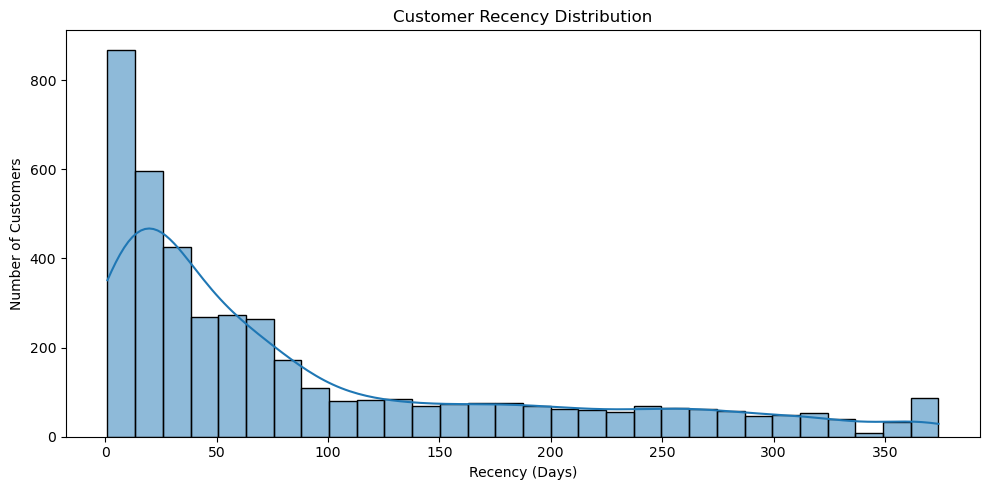

In [41]:
plt.figure(figsize=(10,5))

sns.histplot(rfm["Recency"], bins=30, kde=True)

plt.title("Customer Recency Distribution")
plt.xlabel("Recency (Days)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

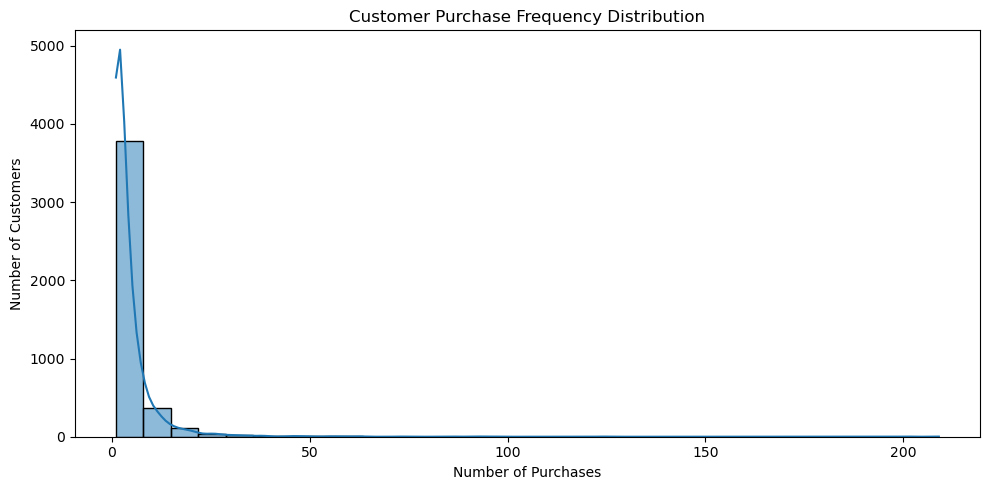

In [42]:
plt.figure(figsize=(10,5))

sns.histplot(rfm["Frequency"], bins=30, kde=True)

plt.title("Customer Purchase Frequency Distribution")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

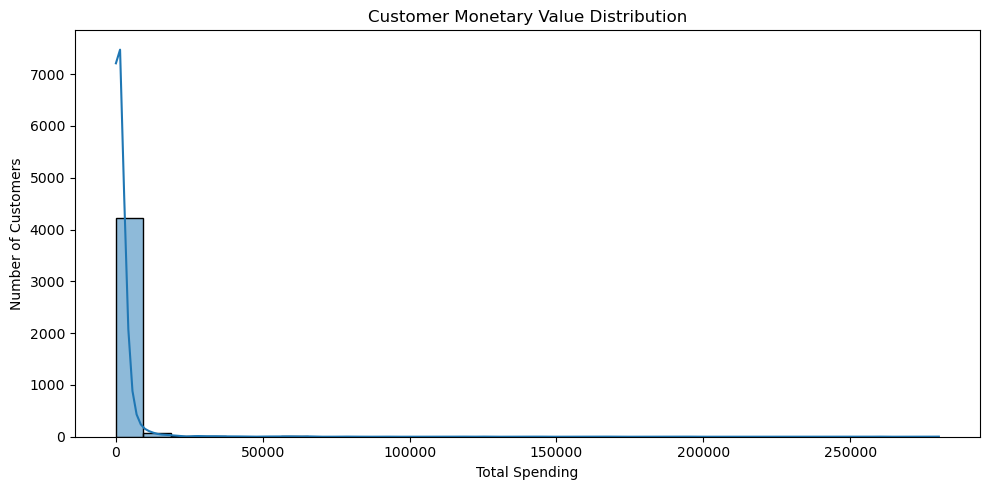

In [43]:
plt.figure(figsize=(10,5))

sns.histplot(rfm["Monetary"], bins=30, kde=True)

plt.title("Customer Monetary Value Distribution")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [44]:
print(rfm.skew())

Recency       1.246048
Frequency    12.067031
Monetary     19.339368
dtype: float64


In [45]:
rfm_model = rfm.copy()

for column in ["Recency", "Frequency", "Monetary"]:
    Q1 = rfm_model[column].quantile(0.25)
    Q3 = rfm_model[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    rfm_model[column] = rfm_model[column].clip(
        lower=lower,
        upper=upper
    )

In [46]:
features = rfm_model[
    ["Recency", "Frequency", "Monetary"]
]

In [47]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(features)

In [48]:
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"],
    index=rfm_model.index
)

rfm_scaled_df.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,2.413382,-0.818035,2.208843
12347,-0.920352,1.155805,2.208843
12348,-0.169233,0.168885,0.556606
12349,-0.745433,-0.818035,0.521992
12350,2.248753,-0.818035,-0.719151


In [49]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_scaled_df)
    
    inertia.append(kmeans.inertia_)

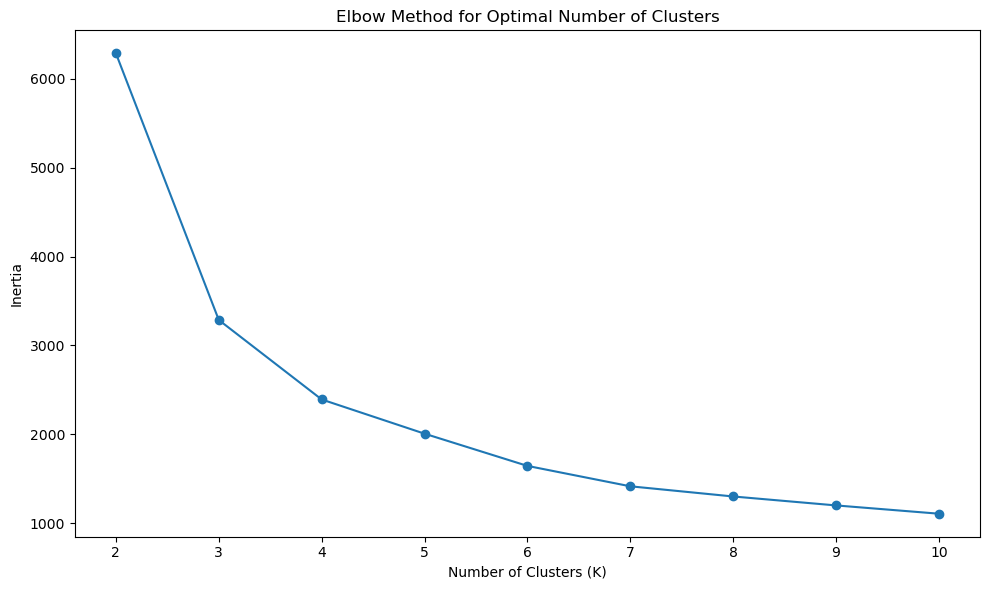

In [50]:
plt.figure(figsize=(10,6))

plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.xticks(range(2, 11))

plt.tight_layout()
plt.show()

In [51]:
k = 4

In [52]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm_model["Cluster"] = kmeans.fit_predict(rfm_scaled_df)

In [53]:
rfm_model.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346,326,1,3691.77,1
12347,2,7,3691.77,3
12348,75,4,1797.24,0
12349,19,1,1757.55,2
12350,310,1,334.40,1


In [54]:
cluster_counts = rfm_model["Cluster"].value_counts().sort_index()

print(cluster_counts)

Cluster
0     853
1    1009
2    1907
3     569
Name: count, dtype: int64


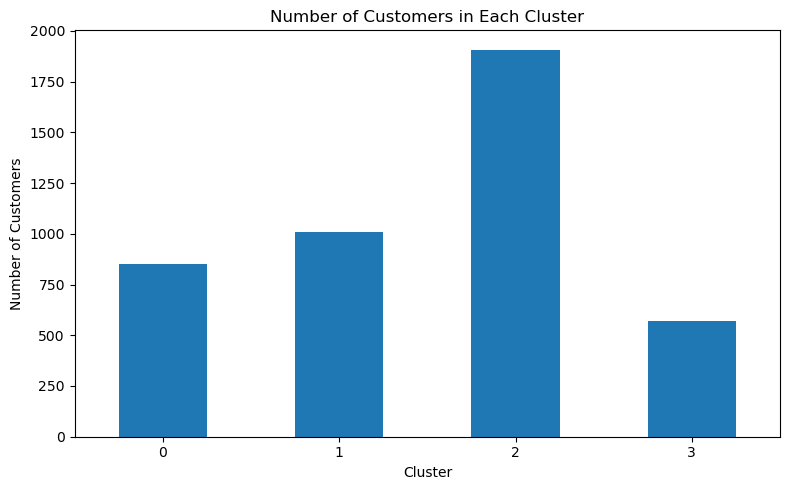

In [55]:
plt.figure(figsize=(8,5))

cluster_counts.plot(kind="bar")

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [56]:
silhouette = silhouette_score(
    rfm_scaled_df,
    rfm_model["Cluster"]
)

print(f"Silhouette Score: {silhouette:.3f}")

Silhouette Score: 0.474


In [57]:
cluster_profile = rfm_model.groupby("Cluster").agg(
    Recency=("Recency", "mean"),
    Frequency=("Frequency", "mean"),
    Monetary=("Monetary", "mean"),
    Customers=("Cluster", "count")
)

cluster_profile

,Recency,Frequency,Monetary,Customers
Cluster,,,,
0,39.828839,5.003517,1951.469896,853
1,248.297324,1.449950,410.916204,1009
2,52.768222,1.984793,539.684380,1907
3,20.323374,9.857645,3373.272935,569


In [58]:
cluster_profile = cluster_profile.round(2)

cluster_profile

,Recency,Frequency,Monetary,Customers
Cluster,,,,
0,39.83,5.00,1951.47,853
1,248.30,1.45,410.92,1009
2,52.77,1.98,539.68,1907
3,20.32,9.86,3373.27,569


In [59]:
cluster_labels = {}

for cluster in cluster_profile.index:
    recency_value = cluster_profile.loc[cluster, "Recency"]
    frequency_value = cluster_profile.loc[cluster, "Frequency"]
    monetary_value = cluster_profile.loc[cluster, "Monetary"]
    
    if (
        recency_value < cluster_profile["Recency"].median()
        and frequency_value > cluster_profile["Frequency"].median()
        and monetary_value > cluster_profile["Monetary"].median()
    ):
        label = "High Value Loyal Customers"
        
    elif (
        recency_value > cluster_profile["Recency"].median()
        and frequency_value < cluster_profile["Frequency"].median()
        and monetary_value < cluster_profile["Monetary"].median()
    ):
        label = "At Risk / Low Value Customers"
        
    elif recency_value < cluster_profile["Recency"].median():
        label = "Recent Customers"
        
    else:
        label = "Occasional Customers"
    
    cluster_labels[cluster] = label

cluster_labels

{0: 'High Value Loyal Customers',
 1: 'At Risk / Low Value Customers',
 2: 'At Risk / Low Value Customers',
 3: 'High Value Loyal Customers'}

In [60]:
rfm_model["Segment"] = rfm_model["Cluster"].map(cluster_labels)

In [61]:
rfm_model.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346,326,1,3691.77,1,At Risk / Low Value Customers
12347,2,7,3691.77,3,High Value Loyal Customers
12348,75,4,1797.24,0,High Value Loyal Customers
12349,19,1,1757.55,2,At Risk / Low Value Customers
12350,310,1,334.40,1,At Risk / Low Value Customers


In [62]:
segment_counts = rfm_model["Segment"].value_counts()

print(segment_counts)

Segment
At Risk / Low Value Customers    2916
High Value Loyal Customers       1422
Name: count, dtype: int64


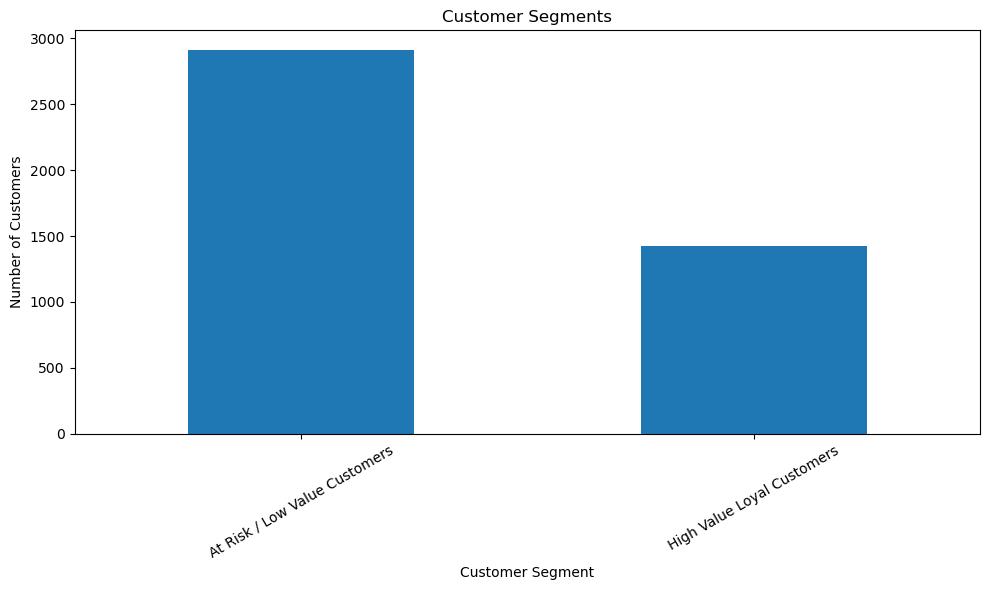

In [63]:
plt.figure(figsize=(10,6))

segment_counts.plot(kind="bar")

plt.title("Customer Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

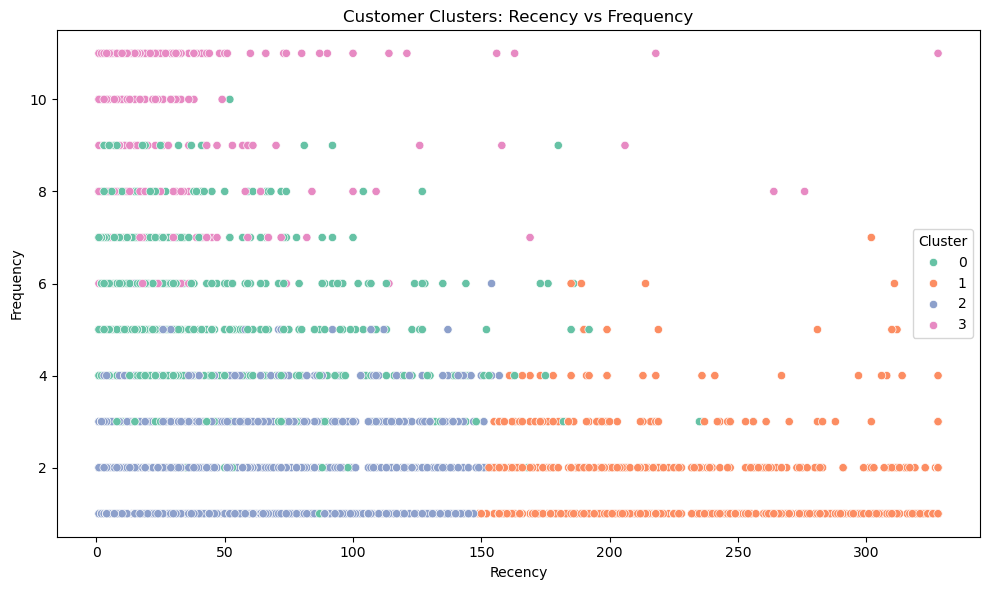

In [65]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm_model,
    x="Recency",
    y="Frequency",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Clusters: Recency vs Frequency")
plt.xlabel("Recency")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

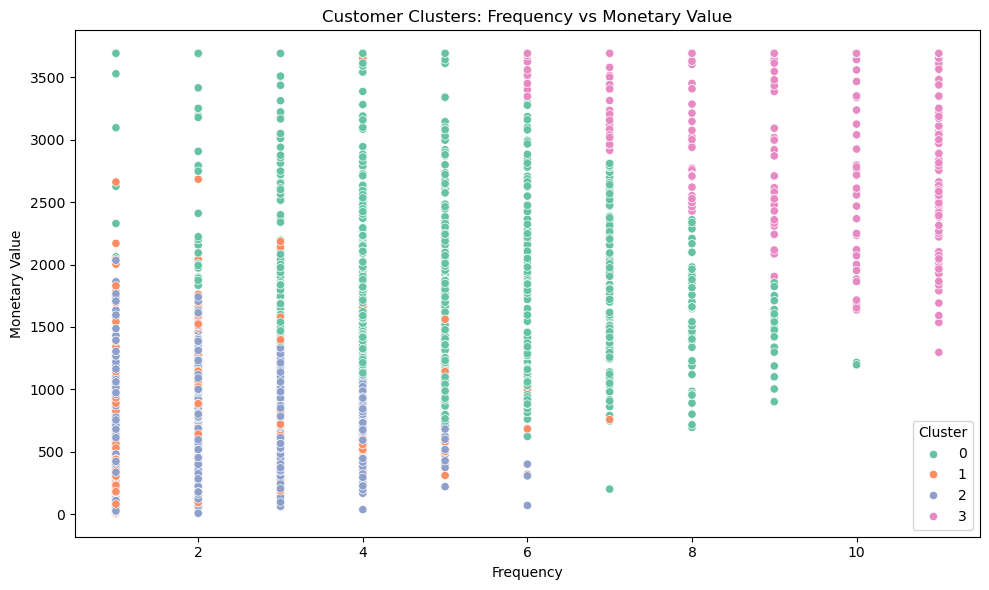

In [66]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm_model,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Clusters: Frequency vs Monetary Value")
plt.xlabel("Frequency")
plt.ylabel("Monetary Value")

plt.tight_layout()
plt.show()

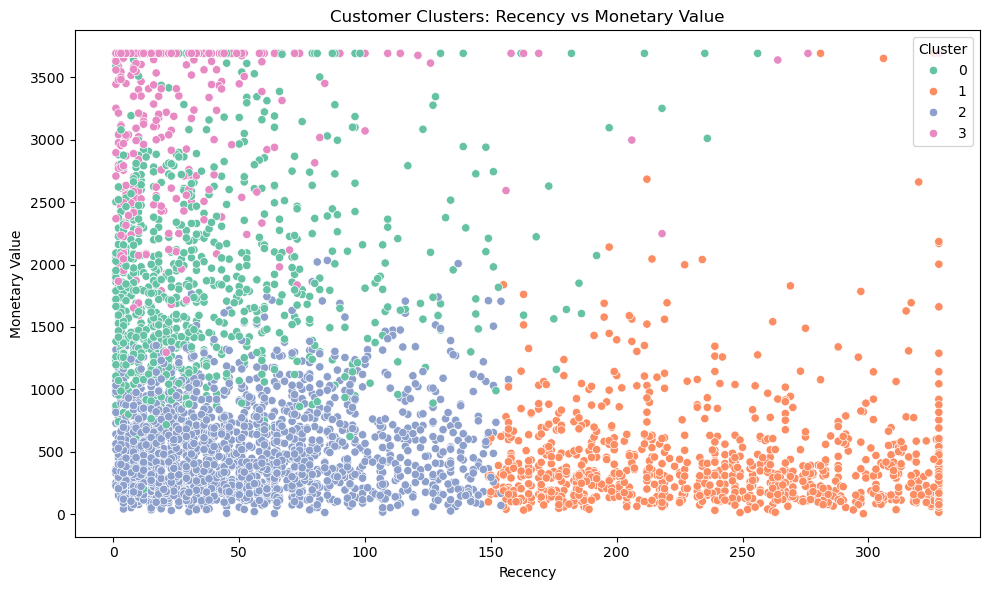

In [67]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm_model,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Clusters: Recency vs Monetary Value")
plt.xlabel("Recency")
plt.ylabel("Monetary Value")

plt.tight_layout()
plt.show()

In [71]:
rfm_model = rfm_model.reset_index()

In [72]:
final_segment_summary = rfm_model.groupby(
    "Segment"
).agg(
    Customers=("CustomerID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).round(2)

final_segment_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
At Risk / Low Value Customers,2916,120.43,1.80,495.13
High Value Loyal Customers,1422,32.02,6.95,2520.39
